In [1]:
!pip install pydicom

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 42.3 MB/s eta 0:00:00


In [2]:
from google.colab import files
import zipfile
import pydicom
import matplotlib.pyplot as plt
from pathlib import Path

In [3]:
uploaded = files.upload()

Saving dicom_dir.zip to dicom_dir.zip


In [4]:
!ls - lh

ls: cannot access '-': No such file or directory
ls: cannot access 'lh': No such file or directory


In [5]:
with zipfile.ZipFile("/content/dicom_dir.zip", "r") as zip_ref:
    zip_ref.extractall("/content/")

In [6]:
!ls

dicom_dir  dicom_dir.zip  sample_data


In [7]:
!ls dicom_dir

ID_0000_AGE_0060_CONTRAST_1_CT.dcm  ID_0050_AGE_0074_CONTRAST_0_CT.dcm
ID_0001_AGE_0069_CONTRAST_1_CT.dcm  ID_0051_AGE_0063_CONTRAST_0_CT.dcm
ID_0002_AGE_0074_CONTRAST_1_CT.dcm  ID_0052_AGE_0072_CONTRAST_0_CT.dcm
ID_0003_AGE_0075_CONTRAST_1_CT.dcm  ID_0053_AGE_0073_CONTRAST_0_CT.dcm
ID_0004_AGE_0056_CONTRAST_1_CT.dcm  ID_0054_AGE_0082_CONTRAST_0_CT.dcm
ID_0005_AGE_0048_CONTRAST_1_CT.dcm  ID_0055_AGE_0071_CONTRAST_0_CT.dcm
ID_0006_AGE_0075_CONTRAST_1_CT.dcm  ID_0056_AGE_0083_CONTRAST_0_CT.dcm
ID_0007_AGE_0061_CONTRAST_1_CT.dcm  ID_0057_AGE_0049_CONTRAST_0_CT.dcm
ID_0008_AGE_0051_CONTRAST_1_CT.dcm  ID_0058_AGE_0082_CONTRAST_0_CT.dcm
ID_0009_AGE_0048_CONTRAST_1_CT.dcm  ID_0059_AGE_0074_CONTRAST_0_CT.dcm
ID_0010_AGE_0060_CONTRAST_1_CT.dcm  ID_0060_AGE_0080_CONTRAST_0_CT.dcm
ID_0011_AGE_0061_CONTRAST_1_CT.dcm  ID_0061_AGE_0074_CONTRAST_0_CT.dcm
ID_0012_AGE_0061_CONTRAST_1_CT.dcm  ID_0062_AGE_0067_CONTRAST_0_CT.dcm
ID_0013_AGE_0060_CONTRAST_1_CT.dcm  ID_0063_AGE_0073_CONTRAST_0_CT.dcm
ID_001

In [8]:
path_ct = Path('/content/dicom_dir')

In [9]:
all_files = list(path_ct.glob("*"))

In [10]:
all_files

[PosixPath('/content/dicom_dir/ID_0095_AGE_0071_CONTRAST_0_CT.dcm'),
 PosixPath('/content/dicom_dir/ID_0048_AGE_0077_CONTRAST_1_CT.dcm'),
 PosixPath('/content/dicom_dir/ID_0004_AGE_0056_CONTRAST_1_CT.dcm'),
 PosixPath('/content/dicom_dir/ID_0030_AGE_0076_CONTRAST_1_CT.dcm'),
 PosixPath('/content/dicom_dir/ID_0010_AGE_0060_CONTRAST_1_CT.dcm'),
 PosixPath('/content/dicom_dir/ID_0052_AGE_0072_CONTRAST_0_CT.dcm'),
 PosixPath('/content/dicom_dir/ID_0028_AGE_0074_CONTRAST_1_CT.dcm'),
 PosixPath('/content/dicom_dir/ID_0075_AGE_0080_CONTRAST_0_CT.dcm'),
 PosixPath('/content/dicom_dir/ID_0012_AGE_0061_CONTRAST_1_CT.dcm'),
 PosixPath('/content/dicom_dir/ID_0056_AGE_0083_CONTRAST_0_CT.dcm'),
 PosixPath('/content/dicom_dir/ID_0072_AGE_0060_CONTRAST_0_CT.dcm'),
 PosixPath('/content/dicom_dir/ID_0096_AGE_0083_CONTRAST_0_CT.dcm'),
 PosixPath('/content/dicom_dir/ID_0099_AGE_0061_CONTRAST_0_CT.dcm'),
 PosixPath('/content/dicom_dir/ID_0002_AGE_0074_CONTRAST_1_CT.dcm'),
 PosixPath('/content/dicom_dir/ID_

In [11]:
pydicom_file = pydicom.dcmread(all_files[0])

In [12]:
pydicom_file

Dataset.file_meta -------------------------------
(0002,0000) File Meta Information Group Length  UL: 196
(0002,0001) File Meta Information Version       OB: b'\x00\x01'
(0002,0002) Media Storage SOP Class UID         UI: CT Image Storage
(0002,0003) Media Storage SOP Instance UID      UI: 1.3.6.1.4.1.14519.5.2.1.6450.9002.578794045870805618560456155391
(0002,0010) Transfer Syntax UID                 UI: Explicit VR Little Endian
(0002,0012) Implementation Class UID            UI: 1.2.40.0.13.1.1.1
(0002,0013) Implementation Version Name         SH: 'dcm4che-1.4.34'
-------------------------------------------------
(0008,0005) Specific Character Set              CS: 'ISO_IR 100'
(0008,0008) Image Type                          CS: ['ORIGINAL', 'PRIMARY', 'AXIAL']
(0008,0012) Instance Creation Date              DA: '19980313'
(0008,0013) Instance Creation Time              TM: '141826'
(0008,0016) SOP Class UID                       UI: CT Image Storage
(0008,0018) SOP Instance UID      

In [13]:
pydicom_file[0x0028, 0x0102]

(0028,0102) High Bit                            US: 15

In [14]:
pydicom_file.AcquisitionTime

'141529'

In [15]:
ct = pydicom_file.pixel_array

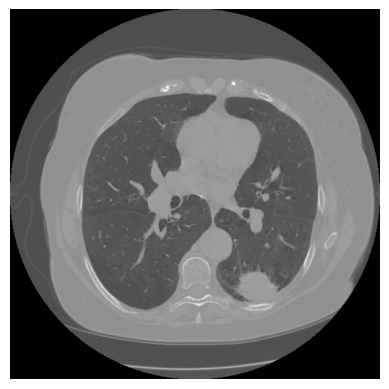

In [16]:
plt.figure()
plt.axis('off')
plt.imshow(ct, cmap='gray')
plt.show()

In [17]:
ct_data = []

for path in all_files:
    data = pydicom.dcmread(path)
    ct_data.append(data)

In [18]:
ct_data = []

for path in all_files:
    data = pydicom.dcmread(path)
    ct_data.append(data)

In [19]:
len(ct_data)

100

In [20]:
for slice in ct_data[:10]:
  print(slice.SliceLocation)

-154.250000
-149
116
-242.750000
-606
-64.6999969482
-221.5
-97.500
-427
-76.5000000000


In [25]:
ct_data_sorted = sorted(ct_data, key=lambda slice:slice.SliceLocation)
for slice in ct_data_sorted[:10]:
  print(slice.SliceLocation)

-1168.4
-948.5
-948.2
-918.5
-901
-874
-874
-816.5
-795.030
-763.5


In [26]:
all_slice = []
for slice in ct_data_sorted:
  all_slice.append(slice.pixel_array)

In [23]:
len(all_slice)

100

In [24]:
all_slice

[array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], dtype=uint16),
 array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], dtype=uint16),
 array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], dtype=uint16),
 array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], dtype=uint16),
 array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 

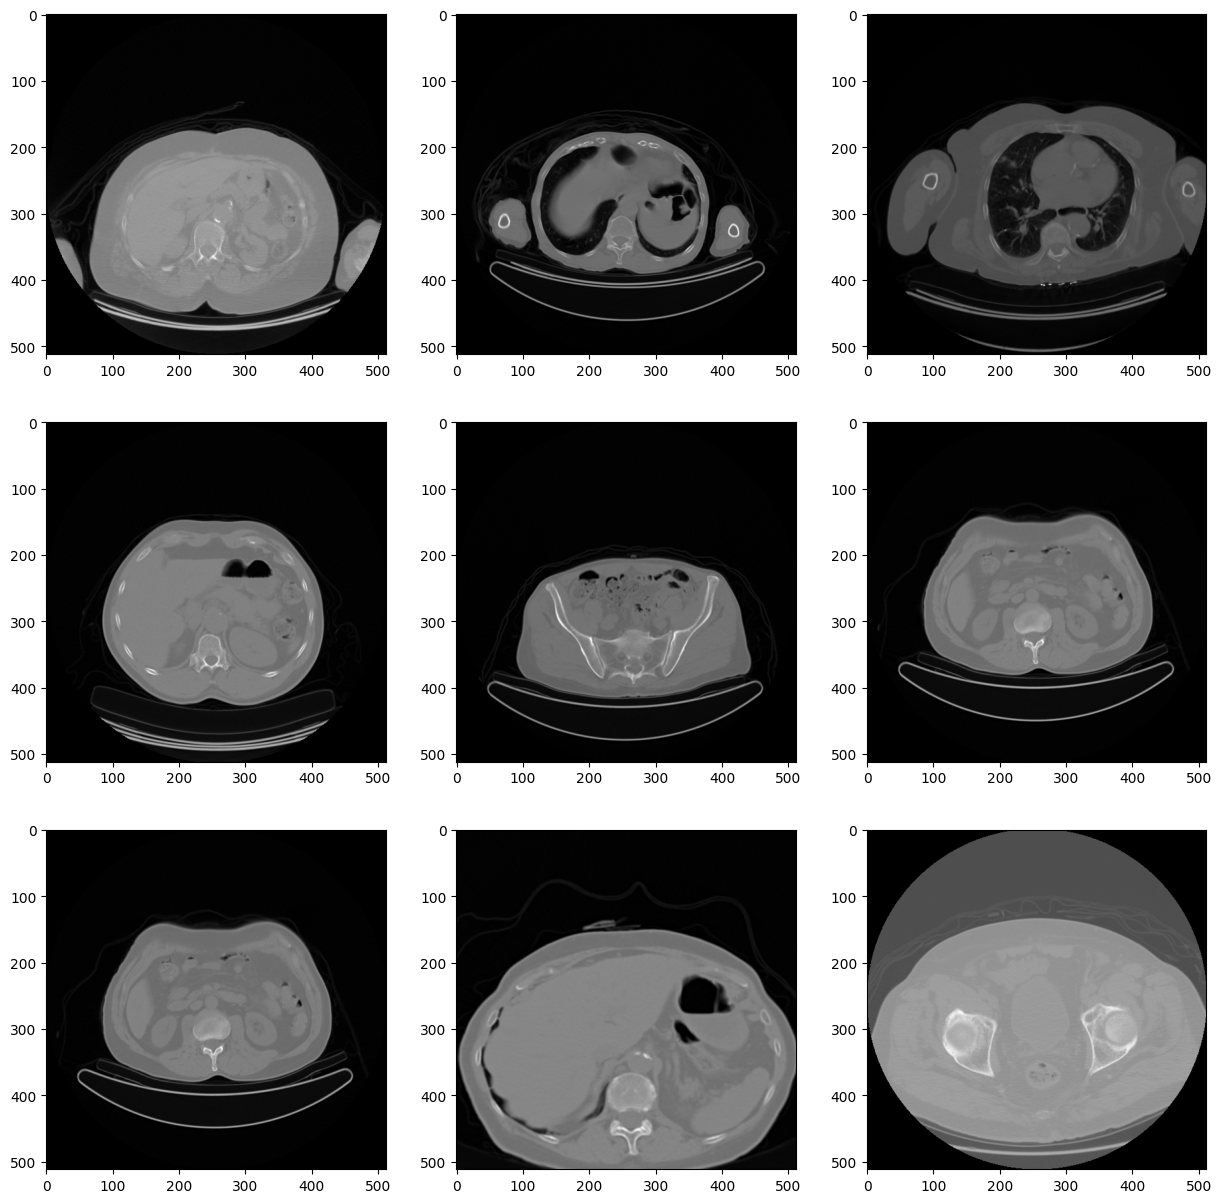

In [27]:
fig , axis = plt.subplots(3, 3, figsize=(15,15))
slice_counter = 0
for i in range(3):
  for j in range(3):
    axis[i][j].imshow(all_slice[slice_counter], cmap='gray')
    slice_counter += 1
plt.show()